## MAPPING PREDICTION RESULTS

* Generating raster maps of neural network prediction results for future drinkning water nitrate

In [4]:
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

In [23]:
# Load Prediction Results
import pandas as pd
import polars as pl
#import pyarrow as pa
#import pyarrow.parquet as pq

future_dir = 'C:/Users/MPennino/OneDrive - Environmental Protection Agency (EPA)/Projects/OASES/Data/Future_NO3/'

filename = 'torch_predictions_current_All_COMID_sw.parquet'
#filename = 'torch_predictions_current_All_COMID_gw.parquet'


# Read the file
preds = pl.read_parquet(future_dir + filename)

# convert to pandas df
preds = preds.to_pandas()

preds.shape, type(preds)

((2643994, 2), pandas.DataFrame)

In [88]:
#preds.columns
pd.options.display.float_format = '{:.2f}'.format # gets it to display in two descipal places
 
#print(preds['Pred_Viol_Prob'].describe())

# Summarize values > 0
temp = preds[preds['Pred_Viol_Prob']>0.01]
print(temp['Pred_Viol_Prob'].describe())



count   528629.00
mean         0.64
std          0.40
min          0.01
25%          0.16
50%          0.88
75%          1.00
max          1.00
Name: Pred_Viol_Prob, dtype: float64


In [12]:
# Read in point shapefiles (HUCs)
#import fiona
import geopandas as gpd

data_dir = "C:/Users/MPennino/OneDrive - Environmental Protection Agency (EPA)/Data/Spatial/"

# Define the path to your shapefile
fp = data_dir + "huc12_points.shp"

# Read the shapefile
huc12_p = gpd.read_file(fp)


In [ ]:
# Read in HUC12 shapefile (1m 4.2s)
import fiona

# 1. Define the path to your .gdb folder
gdb_path = "D:/EnviroAtlas/NHDPlusV2_WBDSnapshot_EnviroAtlas_CONUS.gdb"

# 2. List all feature classes (layers) inside the geodatabase
layers = fiona.listlayers(gdb_path)
print("Available layers:", layers)

# 3. Read a specific feature class into a GeoDataFrame
# (Replace 'your_layer_name' with one of the printed layers)
huc12_s = gpd.read_file(gdb_path, layer="NHDPlusV2_WBDSnapshot_EnviroAtlas_CONUS")

Available layers: ['NHDPlusV2_WBDSnapshot_EnviroAtlas_CONUS']


c:\Users\MPennino\anaconda3\envs\map_env\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: organizePolygons() received a polygon with more than 100 parts.  The processing may be really slow.  You can skip the processing by setting METHOD=SKIP. Further messages of this type will be suppressed.
  return ogr_read(
c:\Users\MPennino\anaconda3\envs\map_env\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: organizePolygons() received a polygon with more than 100 parts. The processing may be really slow.  You can skip the processing by setting METHOD=SKIP, or only make it analyze counter-clock wise parts by setting METHOD=ONLY_CCW if you can assume that the outline of holes is counter-clock wise defined. Further messages of this type will be suppressed.
  return ogr_read(


In [15]:
huc12_s.shape

(82915, 6)

In [ ]:
# Read in NHD Catchments Shapefile (2m 11s)
# 1. Define the path to your .gdb folder
gdb_path = 'D:/ArcGIS/NHDplusV2/Seamless/NHDPlusNationalData/NHDPlusV21_National_Seamless.gdb'

# 2. List all feature classes (layers) inside the geodatabase
layers = fiona.listlayers(gdb_path)
print("Available layers:", layers)

# 3. Read a specific feature class into a GeoDataFrame
# (Replace 'your_layer_name' with one of the printed layers)
cats_s = gpd.read_file(gdb_path, layer="Catchment")
cats_s.shape

Available layers: ['Gage', 'BurnAddLine', 'BurnAddWaterbody', 'LandSea', 'Sink', 'Wall', 'Catchment', 'CatchmentSP', 'NHDArea', 'NHDWaterbody', 'NHDPlusComponentVersions', 'PlusARPointEvent', 'PlusFlow', 'PlusFlowAR', 'NHDFCode', 'DivFracMP', 'BurnLineEvent', 'NHDFlowline_Network', 'NHDFlowline_NonNetwork', 'HUC12', 'GeoNetwork_Junctions', 'N_1_Desc', 'N_1_EDesc', 'N_1_EStatus', 'N_1_ETopo', 'N_1_FloDir', 'N_1_JDesc', 'N_1_JStatus', 'N_1_JTopo', 'N_1_JTopo2', 'N_1_Props']


(2647454, 7)

In [22]:
cats_s = cats_s.rename(columns={'FEATUREID': 'COMID'})
type(cats_s), cats_s.columns


(geopandas.geodataframe.GeoDataFrame,
 Index(['GRIDCODE', 'COMID', 'SOURCEFC', 'AreaSqKM', 'Shape_Length',
        'Shape_Area', 'geometry'],
       dtype='str'))

In [24]:
# Merge Prediction results with Shapefile
#type(cats_s), cats_s.columns
preds_s = cats_s.merge(preds, on="COMID", how="left")
preds_s.shape, preds_s.columns


((2647455, 8),
 Index(['GRIDCODE', 'COMID', 'SOURCEFC', 'AreaSqKM', 'Shape_Length',
        'Shape_Area', 'geometry', 'Pred_Viol_Prob'],
       dtype='str'))

In [25]:
type(preds_s)

geopandas.geodataframe.GeoDataFrame

In [ ]:
epsg_code = preds_s.crs.to_epsg()
print(epsg_code)

#EPSG 4269 is the unique ID for NAD83 (North American Datum 1983), a geographic coordinate system used for mapping locations in North America. 
# It measures positions using latitude and longitude in decimal degrees instead of flat meters

4269


In [ ]:
# Change to project coordinate system with units of meters (1m 26s)
preds_meters = preds_s.to_crs("EPSG:5070")

In [35]:

# Check for how many catchments are missing
preds_meters['Pred_Viol_Prob'].isna().sum()
# 43282
100*43282/len(preds_meters)

1.6348530947645947

In [ ]:
# Convert Shapefile to Raster (8m 2s)
import geopandas as gpd
from geocube.api.core import make_geocube

# 1. Load your shapefile into a GeoDataFrame
#gdf = gpd.read_file("path_to_your_shapefile.shp")

# Optional: Ensure you have a numeric column to burn into the raster grid
# gdf["raster_value"] = 1 

# 2. Rasterize the vector data into an xarray Dataset
cube = make_geocube(
    vector_data=preds_meters,
    measurements=["Pred_Viol_Prob"],  # Column containing pixel values
    resolution=(-1000, 1000)                  # Pixel size (Y, X) - Y is usually negative
)



In [54]:
type(cube)

xarray.core.dataset.Dataset

In [ ]:

# 3. Export the rasterized data directly to a GeoTIFF file
cube["Pred_Viol_Prob"].rio.to_raster("torch_current_preds_COMID_raster_1000m_sw.tif")


NoneType

In [52]:
type("torch_current_preds_COMID_raster_1000m_sw.tif")

str

In [43]:
# States boundary file
states_path = 'D:/ArcGIS/Boundaries/States/conterminous_states_usgs/Conterminous_States_usgs.shp'
states = gpd.read_file(states_path)

In [56]:
# Clip raster to CONUS boundary
import rioxarray

# 1. Load the shapefile and the raster
raster = rioxarray.open_rasterio("torch_current_preds_COMID_raster_1000m_sw.tif")

# 2. Ensure both layers share the same CRS
if states.crs != raster.rio.crs:
    states = states.to_crs(raster.rio.crs)

# 3. Clip the raster to the shapefile geometry
clipped_raster = raster.rio.clip(states.geometry, states.crs, drop=True)

# 4. Save the clipped raster to a new file
clipped_raster.rio.to_raster("torch_current_preds_COMID_raster_1000m_sw_CONUS.tif")

In [50]:
type('torch_current_preds_COMID_raster_1000m_sw.tif')

str

In [89]:
# Create custom continuous colormap from a list of colors
import matplotlib.colors as mcolors
custom_b_y_r = mcolors.LinearSegmentedColormap.from_list("blue_yellow_red", ["blue","green" ,"yellow", "orange", "red"])


### Create a Map Image

<Axes: >

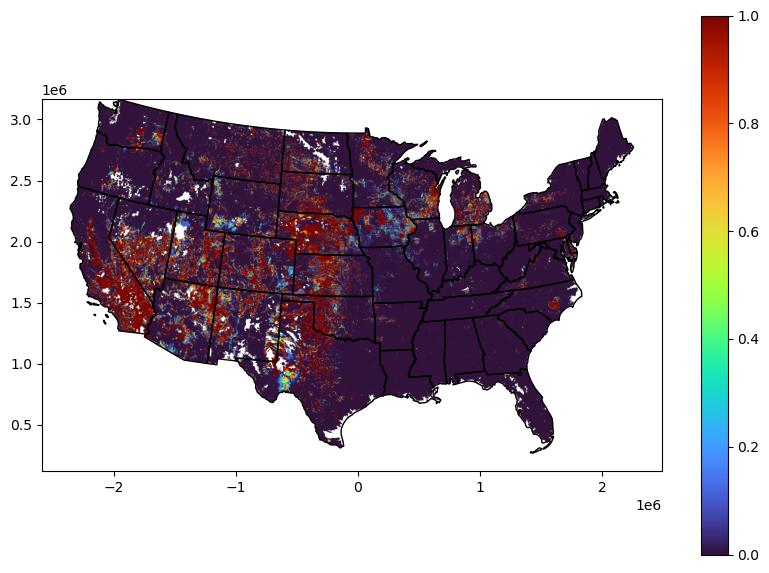

In [139]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

#with rasterio.open(raster_path) as src:

# 1. Open the raster dataset
#raster_path =  "torch_current_preds_COMID_raster_1000m_sw.tif"
raster_path =  "torch_current_preds_COMID_raster_1000m_sw_CONUS.tif"

src = rasterio.open(raster_path)

# 2. Load state boundaries vector file (e.g., Shapefile or GeoJSON)
# See above

# 3. Reproject vector boundaries to match the raster's CRS if needed
if states.crs != src.crs:
    states = states.to_crs(src.crs)

# 4. Create a matplotlib figure and axis
fig, ax = plt.subplots(figsize=(10, 10))

# 5. Plot the raster image on the axis
#show(src, ax=ax, title='Current SWDW Nitrate Violation Risk', cmap='terrain')


# 3. Use rasterio's built-in show function to render it onto the axis
# You can change the colormap (cmap) to options like 'terrain', or 'plasma', inferno, magma, YlOrRd
#  'Accent', 'Accent_r', 'Blues', 'Blues_r', 'BrBG', 'BrBG_r', 'BuGn', 'BuGn_r', 'BuPu', 'BuPu_r', 'CMRmap', 'CMRmap_r', 
# 'Dark2', 'Dark2_r', 'GnBu', 'GnBu_r', 'Grays', 'Grays_r', 'Greens', 'Greens_r', 'Greys', 'Greys_r', 'OrRd', 'OrRd_r', 
# 'Oranges', 'Oranges_r', 'PRGn', 'PRGn_r', 'Paired', 'Paired_r', 'Pastel1', 'Pastel1_r', 'Pastel2', 'Pastel2_r', 'PiYG', 
# 'PiYG_r', 'PuBu', 'PuBuGn', 'PuBuGn_r', 'PuBu_r', 'PuOr', 'PuOr_r', 'PuRd', 'PuRd_r', 'Purples', 'Purples_r', 'RdBu', 
# 'RdBu_r', 'RdGy', 'RdGy_r', 'RdPu', 'RdPu_r', 'RdYlBu', 'RdYlBu_r', 'RdYlGn', 'RdYlGn_r', 'Reds', 'Reds_r', 'Set1', 
# 'Set1_r', 'Set2', 'Set2_r', 'Set3', 'Set3_r', 'Spectral', 'Spectral_r', 'Wistia', 'Wistia_r', 'YlGn', 'YlGnBu', 'YlGnBu_r', 
# 'YlGn_r', 'YlOrBr', 'YlOrBr_r', 'YlOrRd', 'YlOrRd_r', 'afmhot', 'afmhot_r', 'autumn', 'autumn_r', 'berlin', 'berlin_r', 'binary', 
# 'binary_r', 'bone', 'bone_r', 'brg', 'brg_r', 'bwr', 'bwr_r', 'cividis', 'cividis_r', 'cool', 'cool_r', 'coolwarm', 'coolwarm_r', 
# 'copper', 'copper_r', 'cubehelix', 'cubehelix_r', 'flag', 'flag_r', 'gist_earth', 'gist_earth_r', 'gist_gray', 'gist_gray_r', 'gist_grey', 
# 'gist_grey_r', 'gist_heat', 'gist_heat_r', 'gist_ncar', 'gist_ncar_r', 'gist_rainbow', 'gist_rainbow_r', 'gist_stern', 'gist_stern_r', 
# 'gist_yarg', 'gist_yarg_r', 'gist_yerg', 'gist_yerg_r', 'gnuplot', 'gnuplot2', 'gnuplot2_r', 'gnuplot_r', 'gray', 'gray_r', 'grey', 'grey_r', 
# 'hot', 'hot_r', 'hsv', 'hsv_r', 'inferno', 'inferno_r', 'jet', 'jet_r', 'magma', 'magma_r', 'managua', 'managua_r', 'nipy_spectral', 'nipy_spectral_r', 
# 'ocean', 'ocean_r', 'pink', 'pink_r', 'plasma', 'plasma_r', 'prism', 'prism_r', 'rainbow', 'rainbow_r', 'seismic', 'seismic_r', 
# 'spring', 'spring_r', 'summer', 'summer_r', 'tab10', 'tab10_r', 'tab20', 'tab20_r', 'tab20b', 'tab20b_r', 'tab20c', 'tab20c_r', 
# 'terrain', 'terrain_r', 'turbo', 'turbo_r', 'twilight', 'twilight_r', 'twilight_shifted', 'twilight_shifted_r', 'vanimo', 'vanimo_r', 'viridis', 'viridis_r', 'winter', 'winter_r'

image_hidden = show(src, ax=ax, cmap='turbo') # managua_r, nipy_spectral_r, Spectral_r, jet, plasma, RdYlBu_r, turbo

# 4. Add map elements
#ax.set_title("My Raster Map", fontsize=16)
#ax.set_xlabel("Longitude / Easting")
#ax.set_ylabel("Latitude / Northing")

# 5. Extract the image object to construct a matching color bar
fig.colorbar(image_hidden.get_images()[0], ax=ax, shrink=0.7)

# 6. Overlay the state boundaries
states.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.0)

# 6. Save the final map as a high-quality PNG or JPG image
#plt.savefig("raster_map.png", dpi=300, bbox_inches='tight')

# 7. Display the map on screen (optional)
#plt.show()